In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

import calendar

import polars as pl

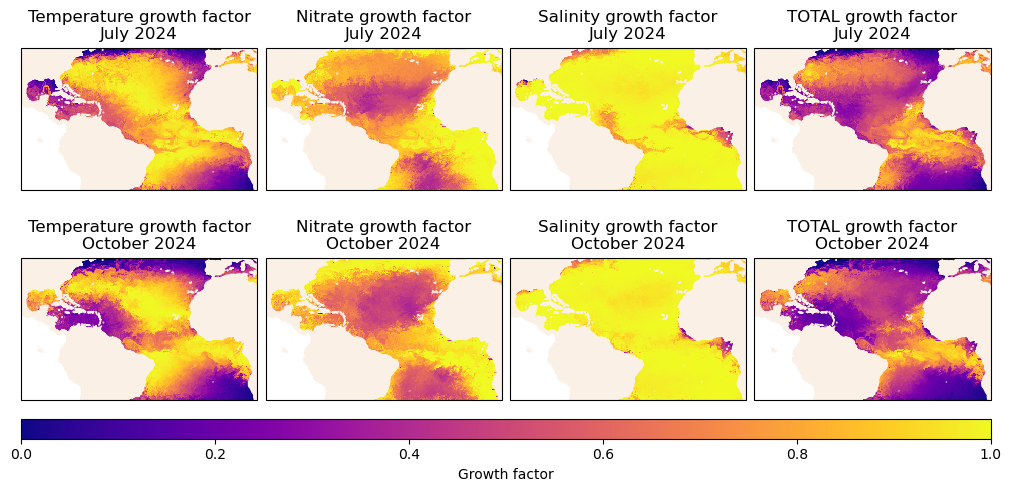

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

titles = ['Temperature', 'Nitrate', 'Salinity', 'TOTAL']
vars = ['lim_temperature', 'lim_nitrogen', 'lim_salinity', 'limitation']

for j, m in enumerate([7, 10]):
    df = pl.read_parquet(f"../Simulations/Simulation_Basin_2024-{m:02d}.parquet")
    for i in range(4):
        ax = axes[j, i]

        to_plot = (
            df.group_by('particle_id')
            .agg([
                pl.col('lon').first().alias('lon'),
                pl.col('lat').first().alias('lat'),
                pl.col(vars[i]).drop_nans().mean().alias('var_mean'),
            ])
            .sort('particle_id')
        )
        cscat = ax.scatter(
            to_plot['lon'], to_plot['lat'], c = to_plot['var_mean'],
            cmap='plasma', s=10, linewidth=0, transform=ccrs.PlateCarree(), zorder=2,
            vmin=0.0, vmax=1, marker='s',
        )

        ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2, color='linen')
        ax.set_extent([-100, 16, -25, 45], crs=ccrs.PlateCarree())
        ax.set_title(f"{titles[i]} growth factor\n{calendar.month_name[m]} 2024")

cbar = fig.colorbar(cscat, ax=axes, orientation='horizontal', pad=0.04, aspect=50, label='Growth factor')

plt.savefig("Figures/Figure7.png", bbox_inches="tight", dpi=300)
plt.show()